In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from tqdm import tqdm
from collections import Counter

Setup Device + Chemins

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

os.makedirs("../models",  exist_ok=True)
os.makedirs("../results", exist_ok=True)

XRAY_PATH    = "../data/xray_aug"
MODEL_PATH   = "../models/efficientnet_xray_best.pth"
HISTORY_P1   = "../results/history_efficientnet_xray_p1.json"
HISTORY_P2   = "../results/history_efficientnet_xray_p2.json"

Device : cuda


DataLoaders

In [3]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

xray_train_loader = DataLoader(
    datasets.ImageFolder(f"{XRAY_PATH}/train", transform=transform),
    batch_size=BATCH_SIZE, shuffle=True
)
xray_val_loader = DataLoader(
    datasets.ImageFolder(f"{XRAY_PATH}/val", transform=transform),
    batch_size=BATCH_SIZE, shuffle=False
)
xray_test_loader = DataLoader(
    datasets.ImageFolder(f"{XRAY_PATH}/test", transform=transform),
    batch_size=BATCH_SIZE, shuffle=False
)

print("✅ DataLoaders X-Ray chargés !")
print(f"   Train  : {len(xray_train_loader.dataset)} images")
print(f"   Val    : {len(xray_val_loader.dataset)} images")
print(f"   Test   : {len(xray_test_loader.dataset)} images")
print(f"   Classes: {xray_train_loader.dataset.class_to_idx}")

✅ DataLoaders X-Ray chargés !
   Train  : 8658 images
   Val    : 699 images
   Test   : 1165 images
   Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


Construire EfficientNetB0

In [4]:
def build_efficientnet(num_classes, device):
    """
    Transfer Learning EfficientNetB0 :
    1. Charger poids pré-entraînés ImageNet
    2. Geler toutes les couches
    3. Remplacer le classifier final
    """

    # ── Charger EfficientNetB0 pré-entraîné ───────────────
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )

    # ── Geler toutes les couches ───────────────────────────
    for param in model.parameters():
        param.requires_grad = False

    # ── Remplacer le classifier final ─────────────────────
    # EfficientNetB0 → in_features = 1280 (différent de ResNet)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(512, num_classes)
    )

    model = model.to(device)

    # ── Résumé ─────────────────────────────────────────────
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters()
                          if p.requires_grad)

    print(f"✅ EfficientNetB0 chargé !")
    print(f"   Total params     : {total_params:,}")
    print(f"   Trainable params : {trainable_params:,}")
    print(f"   Frozen params    : {total_params-trainable_params:,}")
    print(f"   in_features      : {in_features}")
    print(f"   num_classes      : {num_classes}")

    return model

# X-Ray → 2 classes
efficientnet_xray = build_efficientnet(num_classes=2, device=device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:42<00:00, 502kB/s] 


✅ EfficientNetB0 chargé !
   Total params     : 4,664,446
   Trainable params : 656,898
   Frozen params    : 4,007,548
   in_features      : 1280
   num_classes      : 2


Loss, Optimizer, Scheduler

In [6]:
# ── Loss ──────────────────────────────────────────────────
# X-Ray = 2 classes → CrossEntropyLoss
criterion_xray = nn.CrossEntropyLoss()

# ── Optimizer Phase 1 ─────────────────────────────────────
optimizer_xray = optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet_xray.parameters()),
    lr=1e-3
)

# ── Scheduler ─────────────────────────────────────────────
scheduler_xray = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_xray,
    mode    ='min',
    factor  = 0.5,
    patience= 3
)

print("✅ Loss     : CrossEntropyLoss")
print("✅ Optimizer: Adam (lr=1e-3)")
print("✅ Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)")

✅ Loss     : CrossEntropyLoss
✅ Optimizer: Adam (lr=1e-3)
✅ Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


Fonctions Train et Eval

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

Fonction Entraînement avec sauvegarde JSON

In [8]:
def entrainer_modele(model, train_loader, val_loader,
                     criterion, optimizer, scheduler,
                     num_epochs, device,
                     save_path, history_path):

    historique = {
        'train_loss': [], 'train_acc': [],
        'val_loss'  : [], 'val_acc'  : []
    }

    meilleure_val_loss  = float('inf')
    patience_counter    = 0
    EARLY_STOP_PATIENCE = 7

    print(f"{'='*60}")
    print(f"  Début entraînement — {num_epochs} epochs max")
    print(f"  Modèle sauvegardé  : {save_path}")
    print(f"  Historique JSON    : {history_path}")
    print(f"{'='*60}\n")

    for epoch in range(num_epochs):

        # ── Train ──────────────────────────────────────────
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # ── Validation ─────────────────────────────────────
        val_loss, val_acc = eval_epoch(
            model, val_loader, criterion, device
        )

        # ── Scheduler ──────────────────────────────────────
        scheduler.step(val_loss)

        # ── Sauvegarder historique ──────────────────────────
        historique['train_loss'].append(train_loss)
        historique['train_acc'].append(train_acc)
        historique['val_loss'].append(val_loss)
        historique['val_acc'].append(val_acc)

        # ── Sauvegarde JSON après chaque epoch ─────────────
        with open(history_path, 'w') as f:
            json.dump(historique, f, indent=2)

        # ── Affichage ───────────────────────────────────────
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} "
              f"Val Acc: {val_acc:.4f}")

        # ── Sauvegarder meilleur modèle ─────────────────────
        if val_loss < meilleure_val_loss:
            meilleure_val_loss = val_loss
            patience_counter   = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✅ Meilleur modèle sauvegardé ! "
                  f"(val_loss={val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  ⚠️  Pas d'amélioration "
                  f"({patience_counter}/{EARLY_STOP_PATIENCE})")

        # ── Early Stopping ──────────────────────────────────
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n🛑 Early stopping epoch {epoch+1}")
            break

    print(f"\n{'='*60}")
    print(f"  Entraînement terminé !")
    print(f"  Meilleure val_loss : {meilleure_val_loss:.4f}")
    print(f"{'='*60}")

    return historique

Phase 1 : Feature Extraction

In [9]:
print("PHASE 1 — Feature Extraction")
print("Toutes les couches EfficientNet gelées")
print("Seul le classifier est entraîné\n")

historique_p1 = entrainer_modele(
    model        = efficientnet_xray,
    train_loader = xray_train_loader,
    val_loader   = xray_val_loader,
    criterion    = criterion_xray,
    optimizer    = optimizer_xray,
    scheduler    = scheduler_xray,
    num_epochs   = 10,
    device       = device,
    save_path    = "../models/efficientnet_xray_phase1.pth",
    history_path = HISTORY_P1
)

PHASE 1 — Feature Extraction
Toutes les couches EfficientNet gelées
Seul le classifier est entraîné

  Début entraînement — 10 epochs max
  Modèle sauvegardé  : ../models/efficientnet_xray_phase1.pth
  Historique JSON    : ../results/history_efficientnet_xray_p1.json



Epoch [  1/10] Train Loss: 0.1971 Train Acc: 0.9263 | Val Loss: 0.1544 Val Acc: 0.9413
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.1544)


Epoch [  2/10] Train Loss: 0.1447 Train Acc: 0.9464 | Val Loss: 0.1430 Val Acc: 0.9442
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.1430)


Epoch [  3/10] Train Loss: 0.1280 Train Acc: 0.9514 | Val Loss: 0.1400 Val Acc: 0.9413
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.1400)


Epoch [  4/10] Train Loss: 0.1167 Train Acc: 0.9568 | Val Loss: 0.1365 Val Acc: 0.9356
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.1365)


...

Epoch [  6/10] Train Loss: 0.1088 Train Acc: 0.9583 | Val Loss: 0.1389 Val Acc: 0.9413
  ⚠️  Pas d'amélioration (1/7)


Epoch [  7/10] Train Loss: 0.1053 Train Acc: 0.9584 | Val Loss: 0.1421 Val Acc: 0.9442
  ⚠️  Pas d'amélioration (2/7)


Epoch [  8/10] Train Loss: 0.1002 Train Acc: 0.9622 | Val Loss: 0.1320 Val Acc: 0.9499
  ⚠️  Pas d'amélioration (3/7)


Epoch [  9/10] Train Loss: 0.0931 Train Acc: 0.9632 | Val Loss: 0.1245 Val Acc: 0.9514
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.1245)


Epoch [ 10/10] Train Loss: 0.0924 Train Acc: 0.9642 | Val Loss: 0.1516 Val Acc: 0.9371
  ⚠️  Pas d'amélioration (1/7)

  Entraînement terminé !
  Meilleure val_loss : 0.1245


Phase 2 : Fine-Tuning

In [11]:
print("PHASE 2 — Fine-Tuning")
print("Dégel des dernières couches EfficientNet\n")

# ── Dégeler les dernières couches ─────────────────────────
for param in efficientnet_xray.features[-3:].parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in efficientnet_xray.parameters()
                if p.requires_grad)
print(f"Params entraînables après dégel : {trainable:,}\n")

# ── Nouvel optimizer lr plus petit ────────────────────────
optimizer_xray_ft = optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet_xray.parameters()),
    lr=1e-5
)

scheduler_xray_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_xray_ft,
    mode='min', factor=0.5, patience=3
)

historique_p2 = entrainer_modele(
    model        = efficientnet_xray,
    train_loader = xray_train_loader,
    val_loader   = xray_val_loader,
    criterion    = criterion_xray,
    optimizer    = optimizer_xray_ft,
    scheduler    = scheduler_xray_ft,
    num_epochs   = 3,
    device       = device,
    save_path    = MODEL_PATH,
    history_path = HISTORY_P2
)

PHASE 2 — Fine-Tuning
Dégel des dernières couches EfficientNet

Params entraînables après dégel : 3,812,638

  Début entraînement — 3 epochs max
  Modèle sauvegardé  : ../models/efficientnet_xray_best.pth
  Historique JSON    : ../results/history_efficientnet_xray_p2.json



Epoch [  1/3] Train Loss: 0.0832 Train Acc: 0.9672 | Val Loss: 0.1174 Val Acc: 0.9585
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.1174)


Epoch [  2/3] Train Loss: 0.0637 Train Acc: 0.9754 | Val Loss: 0.1192 Val Acc: 0.9485
  ⚠️  Pas d'amélioration (1/7)


Epoch [  3/3] Train Loss: 0.0588 Train Acc: 0.9760 | Val Loss: 0.1132 Val Acc: 0.9485
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.1132)

  Entraînement terminé !
  Meilleure val_loss : 0.1132


Visualiser courbes depuis JSON

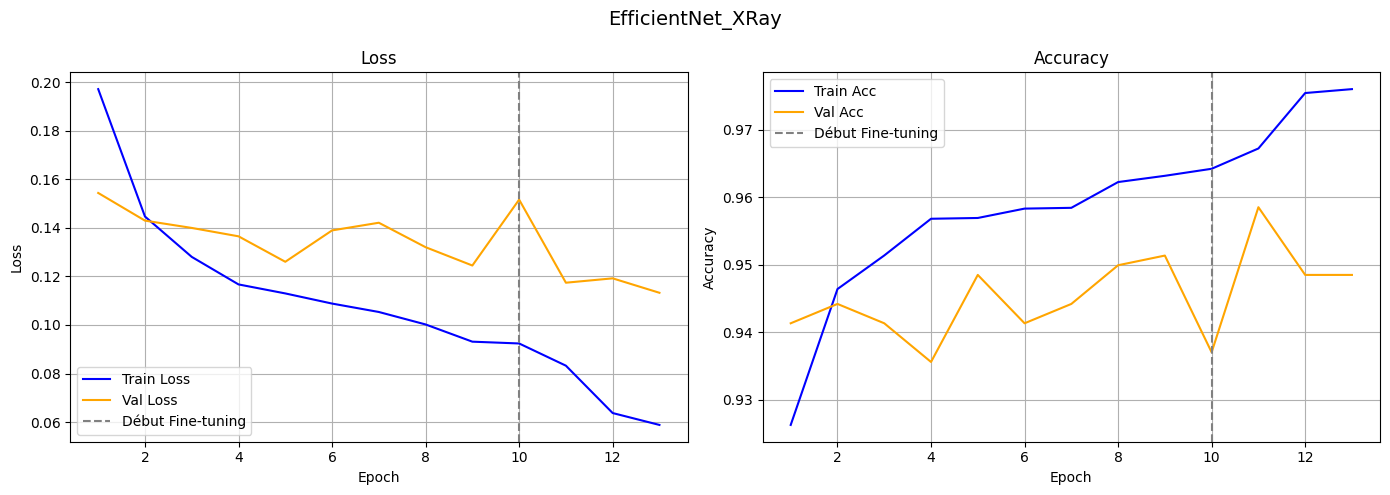


  Résumé — EfficientNet_XRay
  Phase 1        : 10 epochs
  Phase 2        : 3 epochs
  Meilleure Val Loss : 0.1132
  Meilleure Val Acc  : 95.85%


In [12]:
def plot_depuis_json(path_p1, path_p2, titre):

    with open(path_p1, 'r') as f:
        hist1 = json.load(f)
    with open(path_p2, 'r') as f:
        hist2 = json.load(f)

    train_loss = hist1['train_loss'] + hist2['train_loss']
    val_loss   = hist1['val_loss']   + hist2['val_loss']
    train_acc  = hist1['train_acc']  + hist2['train_acc']
    val_acc    = hist1['val_acc']    + hist2['val_acc']
    epochs     = range(1, len(train_loss) + 1)
    sep        = len(hist1['train_loss'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(titre, fontsize=14)

    # ── Loss ───────────────────────────────────────────────
    axes[0].plot(epochs, train_loss, label='Train Loss', color='blue')
    axes[0].plot(epochs, val_loss,   label='Val Loss',   color='orange')
    axes[0].axvline(x=sep, color='gray',
                    linestyle='--', label='Début Fine-tuning')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # ── Accuracy ───────────────────────────────────────────
    axes[1].plot(epochs, train_acc, label='Train Acc', color='blue')
    axes[1].plot(epochs, val_acc,   label='Val Acc',   color='orange')
    axes[1].axvline(x=sep, color='gray',
                    linestyle='--', label='Début Fine-tuning')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"../results/{titre}.png")
    plt.show()

    print(f"\n{'='*45}")
    print(f"  Résumé — {titre}")
    print(f"{'='*45}")
    print(f"  Phase 1        : {len(hist1['train_loss'])} epochs")
    print(f"  Phase 2        : {len(hist2['train_loss'])} epochs")
    print(f"  Meilleure Val Loss : {min(val_loss):.4f}")
    print(f"  Meilleure Val Acc  : {max(val_acc)*100:.2f}%")

plot_depuis_json(HISTORY_P1, HISTORY_P2, "EfficientNet_XRay")

Évaluation sur Test Set

Test: 100%|██████████| 37/37 [00:34<00:00,  1.06it/s]


  ÉVALUATION — EfficientNet X-Ray
              precision    recall  f1-score   support

      NORMAL       0.90      0.94      0.92       316
   PNEUMONIA       0.98      0.96      0.97       849

    accuracy                           0.96      1165
   macro avg       0.94      0.95      0.95      1165
weighted avg       0.96      0.96      0.96      1165

  AUC-ROC : 0.9923


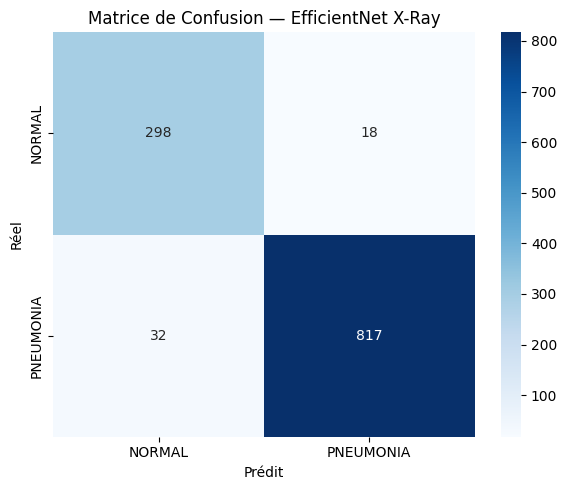


✅ Métriques sauvegardées !


In [13]:
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score)
import seaborn as sns

# ── Charger meilleur modèle ────────────────────────────────
efficientnet_xray.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)
efficientnet_xray.eval()

# ── Prédictions sur tout le test set ──────────────────────
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in tqdm(xray_test_loader, desc="Test"):
        images  = images.to(device)
        outputs = efficientnet_xray(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

classes    = list(xray_test_loader.dataset.class_to_idx.keys())

# ── Métriques ──────────────────────────────────────────────
print("=" * 55)
print("  ÉVALUATION — EfficientNet X-Ray")
print("=" * 55)
print(classification_report(all_labels, all_preds,
                             target_names=classes))

# ── AUC-ROC ────────────────────────────────────────────────
auc = roc_auc_score(all_labels, all_probs[:, 1])
print(f"  AUC-ROC : {auc:.4f}")

# ── Matrice de confusion ───────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.title("Matrice de Confusion — EfficientNet X-Ray")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("../results/confusion_efficientnet_xray.png")
plt.show()

# ── Sauvegarder métriques JSON ─────────────────────────────
metriques = {
    "model"   : "EfficientNetB0",
    "dataset" : "X-Ray",
    "accuracy": float((all_preds == all_labels).mean()),
    "auc_roc" : float(auc),
    "classes" : classes
}

with open("../results/metriques_efficientnet_xray.json", "w") as f:
    json.dump(metriques, f, indent=2)

print("\n✅ Métriques sauvegardées !")